In [6]:
import shutil
import os

src = "/kaggle/input/ao-data"
dst = "/kaggle/working/ao_data"
if not os.path.exists(dst):
    shutil.copytree(src, dst)

In [9]:
from ultralytics import YOLO
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from pytorch_grad_cam import GradCAM, XGradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [18]:
import torch
import torch.nn as nn
import timm


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [ ]:
# Load YOLOv11S trained weights (use correct path if different)
yolo = YOLO('/kaggle/working/ao_data/best_yolov11.pt')  


In [ ]:
CONFIG = {
    'img_size': 256,
    'age_embed_dim': 16
    
}


In [16]:
n_classes = 8


In [ ]:
class AgeAwareConvNeXt(nn.Module):
    def __init__(self, num_classes, age_embed_dim=16):
        super(AgeAwareConvNeXt, self).__init__()
        self.backbone = timm.create_model('convnext_small', pretrained=True, num_classes=0)
        backbone_out_dim = self.backbone.num_features
        self.age_embed = nn.Sequential(
            nn.Linear(1, age_embed_dim),
            nn.ReLU(),
            nn.BatchNorm1d(age_embed_dim),
            nn.Dropout(0.1),
            nn.Linear(age_embed_dim, age_embed_dim),
            nn.ReLU(),
            nn.BatchNorm1d(age_embed_dim),
            nn.Dropout(0.1)
        )
        self.age_predictor = nn.Sequential(
            nn.Linear(age_embed_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        combined_dim = backbone_out_dim + age_embed_dim
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(combined_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )
    def forward(self, x, age, return_age_pred=False):
        img_features = self.backbone(x)
        age = age.unsqueeze(1)
        age_features = self.age_embed(age)
        age_pred = self.age_predictor(age_features).squeeze(1)
        combined = torch.cat([img_features, age_features], dim=1)
        output = self.classifier(combined)
        if return_age_pred:
            return output, age_pred
        return output


In [ ]:

model = AgeAwareConvNeXt(num_classes=n_classes, age_embed_dim=CONFIG["age_embed_dim"])
model.load_state_dict(torch.load("/kaggle/working/ao_data/best_age_convnext_.pth", map_location=device))
model.eval()
model.to(device)
class_names = ['22r-D-2.1', '22u-D-2.1', '23r-E-1', '23r-E-2.1', '23r-M-2.1', '23r-M-3.1', '23u-E-7', '23u-M-2.1']

model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

In [21]:
test_transform = transforms.Compose([
    # Add your custom CLAHE if needed here
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [ ]:
# Load image single fracture
img_path = '/kaggle/working/ao_data/fracture/fracture/fracture_images/0006_0290481819_01_WRI-R2_M011.png'
img_cv2 = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

# Run YOLOv11 inference - returns detections with bounding boxes and classes
results = yolo(img_path)  

boxes = results[0].boxes.xyxy.cpu().numpy()  # [[x1, y1, x2, y2], ...]
scores = results[0].boxes.conf.cpu().numpy()  # [confidence,...]
classes = results[0].boxes.cls.cpu().numpy().astype(int)  # [class,...]



image 1/1 /kaggle/working/ao_data/fracture/fracture/fracture_images/0006_0290481819_01_WRI-R2_M011.png: 512x224 1 fracture, 386.1ms
Speed: 21.6ms preprocess, 386.1ms inference, 35.3ms postprocess per image at shape (1, 3, 512, 224)


In [ ]:
patient_age = int(input('Enter patient age for AO (0-19): '))
# user input or set programmatically


Enter patient age for AO (0-19):  11


In [25]:
ao_results = []
for i, (box, score, det_class) in enumerate(zip(boxes, scores, classes)):
    x1, y1, x2, y2 = map(int, box)
    crop = img_rgb[y1:y2, x1:x2]
    pil_crop = Image.fromarray(crop)
    crop_tensor = test_transform(pil_crop).unsqueeze(0).to(device)
    age_normalized = patient_age / 17.0
    age_tensor = torch.tensor([age_normalized], dtype=torch.float32).to(device)
    with torch.no_grad():
        output = model(crop_tensor, age_tensor)
        probs = torch.softmax(output, dim=1)
        pred_class = probs.argmax(dim=1).item()
        confidence = probs[0, pred_class].item()
    ao_results.append({
        "box": (x1, y1, x2, y2),
        "ao_pred": pred_class,
        "ao_conf": confidence,
        "crop_tensor": crop_tensor,
        "age_tensor": age_tensor,
        "crop": crop
    })

    # GradCAM Overlay
    target_layer = model.backbone.stages[-1]
    class_output = [ClassifierOutputTarget(pred_class)]
    class AOGradCAMWrapper(torch.nn.Module):
        def __init__(self, model, age_tensor):
            super().__init__()
            self.model = model
            self.age_tensor = age_tensor
        def forward(self, x):
            batch_size = x.shape[0]
            age_batch = self.age_tensor.expand(batch_size)
            return self.model(x, age_batch)
    wrapped_model = AOGradCAMWrapper(model, age_tensor)
    gradcam = GradCAM(model=wrapped_model, target_layers=[target_layer])
    grayscale_cam = gradcam(input_tensor=crop_tensor, targets=class_output)[0]
    crop_normalized = cv2.resize(crop.astype(np.float32) / 255., (224,224))
    cam_resized = cv2.resize(grayscale_cam, (crop_normalized.shape[1], crop_normalized.shape[0]))
    overlay_img = show_cam_on_image(crop_normalized, cam_resized, use_rgb=True)
    ao_results[-1]["gradcam_overlay"] = overlay_img

    # XGradCAM Overlay (optional)
    xgradcam = XGradCAM(model=wrapped_model, target_layers=[target_layer])
    grayscale_cam_xg = xgradcam(input_tensor=crop_tensor, targets=class_output)[0]
    cam_resized_xg = cv2.resize(grayscale_cam_xg, (crop_normalized.shape[1], crop_normalized.shape[0]))
    overlay_img_xg = show_cam_on_image(crop_normalized, cam_resized_xg, use_rgb=True)
    ao_results[-1]["xgradcam_overlay"] = overlay_img_xg


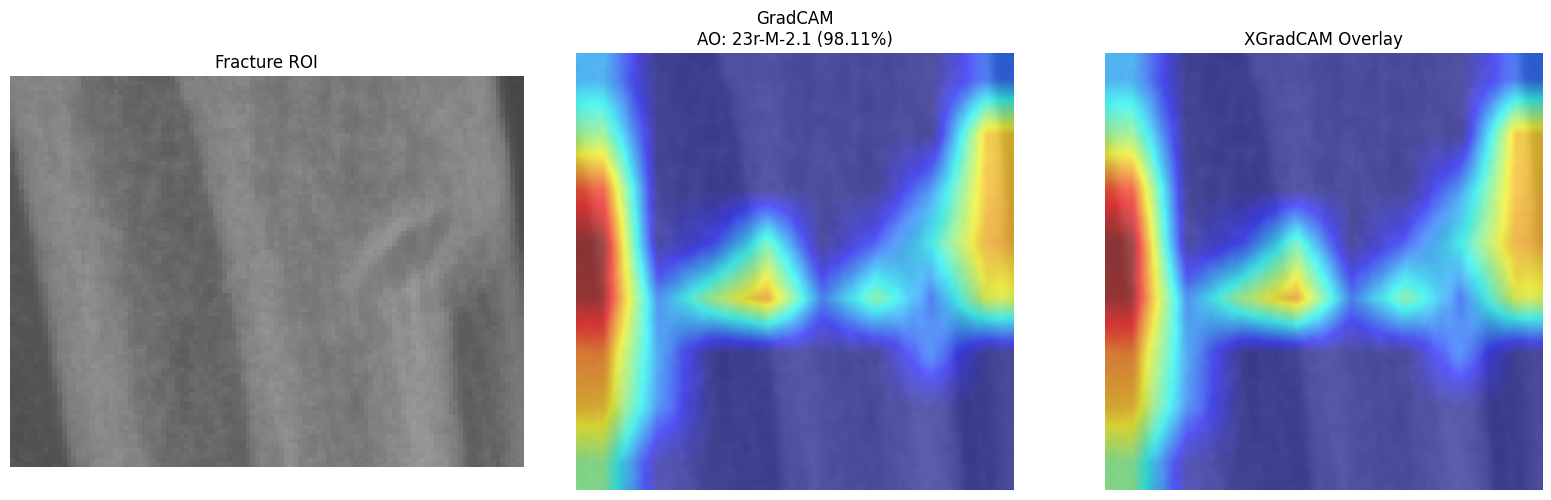

In [26]:
for i, res in enumerate(ao_results):
    fig, axes = plt.subplots(1, 3, figsize=(16,5))
    axes[0].imshow(res["crop"])
    axes[0].set_title("Fracture ROI")
    axes[0].axis('off')
    axes[1].imshow(res["gradcam_overlay"])
    axes[1].set_title(f"GradCAM\nAO: {class_names[res['ao_pred']]} ({res['ao_conf']:.2%})")
    axes[1].axis('off')
    axes[2].imshow(res["xgradcam_overlay"])
    axes[2].set_title("XGradCAM Overlay")
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()


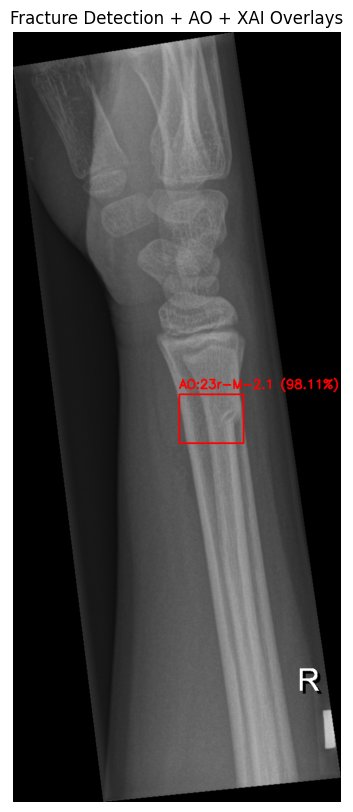

In [27]:
img_copy = img_rgb.copy()
for res in ao_results:
    x1, y1, x2, y2 = res["box"]
    cv2.rectangle(img_copy, (x1, y1), (x2, y2), (255,0,0), 2)
    txt = f"AO:{class_names[res['ao_pred']]} ({res['ao_conf']:.2%}) Age:{patient_age}"
    cv2.putText(img_copy, txt, (x1, max(y1-10,0)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)
plt.figure(figsize=(10,10))
plt.imshow(img_copy)
plt.title("Fracture Detection + AO + XAI Overlays")
plt.axis('off')
plt.show()
